In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("dataset_motif_level.pkl")
df.head()

,squiggle,motifs
0,"[[671, 498, 504, 526, 502, 512, 527, 528, 517,...",ltm8_1x1|ltm8_2x1|ltm8_4x2|ltm8_5x7|ltm8_6x4|l...
1,"[[540, 415, 425, 463, 470, 494, 499, 498, 494,...",ltm8_2x1|ltm8_3x4|ltm8_6x8|ltm8_7x2|ltm8_7x2|l...
2,"[[899, 851, 806, 779, 729, 713, 673, 659, 632,...",ltm8_2x1|ltm8_4x8|ltm8_5x1|ltm8_6x7|ltm8_7x1|l...
3,"[[522, 513, 517, 522, 515, 503, 518, 523, 524,...",ltm8_1x1|ltm8_2x1|ltm8_3x5|ltm8_4x1|ltm8_5x6|l...
4,[],ltm8_2x1|ltm8_4x7|ltm8_5x4|ltm8_6x4|ltm8_6x7|l...


In [3]:
# Get the number of missing values in squiggles and drop those columns
squiggles = df['squiggle'].to_numpy()
motifs = df['motifs'].to_numpy()
counter = 0
squiggles_ = []
label_ = []

for i in range(len(squiggles)):
    if len(squiggles[i]) != 0:
        squiggles_.append(squiggles[i][0])
        label_.append(motifs[i])

print(len(squiggles_))
print(len(label_))
        

8006
8006


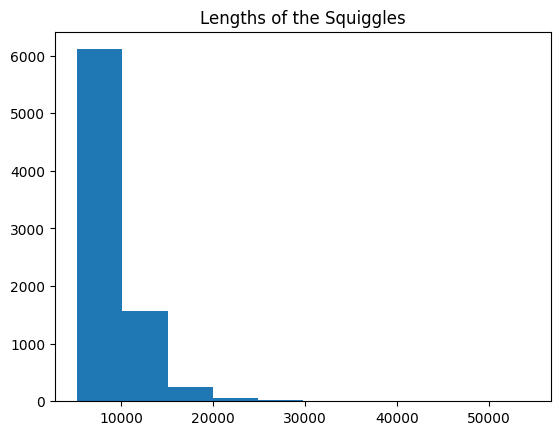

In [4]:
lengths = [len(i) for i in squiggles_]

plt.hist(lengths)
plt.title("Lengths of the Squiggles")
plt.show()

Thinking of 
1. Normalizing between 0 and 1
2. Cleaning using FFT
3. Can Feed directly into CNN model architecture

4. Represent label as one hot encoding - so total number of unique motifs that are identified and a one hot encoding representing which ones are found and then vectorizing it [1,0,1,0,0000] etc

Time to create the model 

1) Pad inputs to the same length (which is like the max length)
2) One hot encoded label - see all the unique values (initially just the number of unique motif identifiers)
3) Input to conv network that learns the features
4) Feedforward RNN Encoder
5) Pass context vector to RNN Decoder
6) output the one hot encoded label

In [8]:


import torch
import torch.nn as nn


class CNNLayerNorm(nn.Module):
    """Layer normalization built for cnns input"""
    def __init__(self, n_feats):
        super(CNNLayerNorm, self).__init__()
        self.layer_norm = nn.LayerNorm(n_feats)

    def forward(self, x):
        # x (batch, channel, feature, time)
        x = x.transpose(2, 3).contiguous() # (batch, channel, time, feature)
        x = self.layer_norm(x)
        return x.transpose(2, 3).contiguous() # (batch, channel, feature, time) 

class ResidualCNN(nn.Module):
    """Residual CNN inspired by https://arxiv.org/pdf/1603.05027.pdf
        except with layer norm instead of batch norm
    """
    def __init__(self, in_channels, out_channels, kernel, stride, dropout, n_feats):
        super(ResidualCNN, self).__init__()

        self.cnn1 = nn.Conv2d(in_channels, out_channels, kernel, stride, padding=kernel//2)
        self.cnn2 = nn.Conv2d(out_channels, out_channels, kernel, stride, padding=kernel//2)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.layer_norm1 = CNNLayerNorm(n_feats)
        self.layer_norm2 = CNNLayerNorm(n_feats)

    def forward(self, x):
        residual = x  # (batch, channel, feature, time)
        x = self.layer_norm1(x)
        x = F.gelu(x)
        x = self.dropout1(x)
        x = self.cnn1(x)
        x = self.layer_norm2(x)
        x = F.gelu(x)
        x = self.dropout2(x)
        x = self.cnn2(x)
        x += residual
        return x # (batch, channel, feature, time)
        
class BidirectionalGRU(nn.Module):

    def __init__(self, rnn_dim, hidden_size, dropout, batch_first):
        super(BidirectionalGRU, self).__init__()

        self.BiGRU = nn.GRU(
            input_size=rnn_dim, hidden_size=hidden_size,
            num_layers=1, batch_first=batch_first, bidirectional=True)
        self.layer_norm = nn.LayerNorm(rnn_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.layer_norm(x)
        x = F.gelu(x)
        x, _ = self.BiGRU(x)
        x = self.dropout(x)
        return x


##### input_length = 20000 # Length of longest squiggle


"""
class MotifModel(nn.Module):

    def __init__(self
"""


class SpeechRecognitionModel(nn.Module):
    """Speech Recognition Model Inspired by DeepSpeech 2"""

    def __init__(self, n_cnn_layers, n_rnn_layers, rnn_dim, n_class, n_feats, stride=2, dropout=0.1):
        super(SpeechRecognitionModel, self).__init__()
        n_feats = n_feats//2
        self.cnn = nn.Conv2d(1, 32, 3, stride=stride, padding=3//2)  # cnn for extracting heirachal features

        # n residual cnn layers with filter size of 32
        self.rescnn_layers = nn.Sequential(*[
            ResidualCNN(32, 32, kernel=3, stride=1, dropout=dropout, n_feats=n_feats) 
            for _ in range(n_cnn_layers)
        ])
        self.fully_connected = nn.Linear(n_feats*32, rnn_dim)
        self.birnn_layers = nn.Sequential(*[
            BidirectionalGRU(rnn_dim=rnn_dim if i==0 else rnn_dim*2,
                             hidden_size=rnn_dim, dropout=dropout, batch_first=i==0)
            for i in range(n_rnn_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(rnn_dim*2, rnn_dim),  # birnn returns rnn_dim*2
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(rnn_dim, n_class)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.rescnn_layers(x)
        sizes = x.size()
        x = x.view(sizes[0], sizes[1] * sizes[2], sizes[3])  # (batch, feature, time)
        x = x.transpose(1, 2) # (batch, time, feature)
        x = self.fully_connected(x)
        x = self.birnn_layers(x)
        x = self.classifier(x)
        return x

SpeechRecognitionModel(1,3,200,4,20)

Normalise - Clean - Pad - One Hot Encode